# Desmatamento e Preservação Ambiental no Brasil

**Autor:** Thalles Órion Volcov Pitz
**Disciplina:** Linguagem de Programação — Análise e Visualização de Dados com Python
**Avaliação:** G1

## 1. Introdução ao problema

O desmatamento é um dos principais problemas ambientais do Brasil. Ele reduz a vegetação nativa, aumenta as emissões de carbono, favorece as queimadas e ameaça a biodiversidade. Acompanhar esses números ao longo do tempo ajuda a entender onde o problema é maior e quais fatores caminham junto com ele.

Neste notebook analiso uma base com registros mensais de 20 estados brasileiros, de 2015 a 2024. As perguntas que guiam o trabalho são:

1. O desmatamento aumentou ou diminuiu ao longo dos anos?
2. Quais regiões, estados e biomas têm as maiores médias de área desmatada?
3. Existe relação entre desmatamento, queimadas, chuva, temperatura e emissões de CO₂?
4. Como os registros se distribuem entre os níveis de risco ambiental?

## 2. Explicação da base de dados

A base `simulacao_desmatamento_brasil.csv` tem uma linha por estado, bioma e mês. Ela é uma **simulação** feita para fins didáticos. Por isso, algumas combinações (por exemplo, o estado do Amazonas aparecer com o bioma Caatinga) não correspondem à geografia real.

| Coluna | Significado |
|---|---|
| ano, mes, data | Período do registro |
| regiao, uf | Região e estado |
| bioma | Bioma do registro |
| area_desmatada_km2 | Área desmatada no mês (km²) |
| area_preservada_km2 | Área preservada (km²) |
| focos_queimada | Quantidade de focos de queimada |
| chuva_mm | Chuva no mês (mm) |
| temperatura_media | Temperatura média (°C) |
| emissoes_co2 | Emissões de CO₂ |
| unidades_conservacao | Número de unidades de conservação |
| nivel_risco | Baixo, Médio, Alto ou Crítico |

## 3. Leitura dos dados

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", "{:,.2f}".format)

In [2]:
df = pd.read_csv("../dados/simulacao_desmatamento_brasil.csv", encoding="utf-8-sig")
df.head()

,ano,mes,data,regiao,uf,bioma,area_desmatada_km2,area_preservada_km2,focos_queimada,chuva_mm,temperatura_media,emissoes_co2,unidades_conservacao,nivel_risco
0,2015,1,2015-01-01,Norte,AM,Caatinga,75.46,"43,451.70",16,46.90,27.50,"82,964.84",35,Alto
1,2015,1,2015-01-01,Norte,PA,Cerrado,69.69,"66,513.34",10,66.70,27.20,"31,417.01",7,Médio
2,2015,1,2015-01-01,Norte,PA,Pampa,25.99,"2,580.54",18,23.20,26.30,"51,231.24",33,Médio
3,2015,1,2015-01-01,Norte,RO,Caatinga,147.33,"78,446.65",14,123.90,24.70,"24,510.33",27,Baixo
4,2015,1,2015-01-01,Norte,TO,Caatinga,165.34,"51,615.00",16,60.40,25.20,"71,148.30",19,Alto


In [3]:
print("Linhas e colunas:", df.shape)
df.info()

Linhas e colunas: (4440, 14)
<class 'pandas.DataFrame'>
RangeIndex: 4440 entries, 0 to 4439
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ano                   4440 non-null   int64  
 1   mes                   4440 non-null   int64  
 2   data                  4440 non-null   str    
 3   regiao                4440 non-null   str    
 4   uf                    4440 non-null   str    
 5   bioma                 4440 non-null   str    
 6   area_desmatada_km2    4440 non-null   float64
 7   area_preservada_km2   4440 non-null   float64
 8   focos_queimada        4440 non-null   int64  
 9   chuva_mm              4440 non-null   float64
 10  temperatura_media     4440 non-null   float64
 11  emissoes_co2          4440 non-null   float64
 12  unidades_conservacao  4440 non-null   int64  
 13  nivel_risco           4440 non-null   str    
dtypes: float64(5), int64(4), str(5)
memory usage: 485.8 KB

## 4. Limpeza e preparação

Antes de analisar, confiro valores nulos, duplicados, tipos das colunas, consistência entre as colunas de data e valores fora do esperado.

In [4]:
print("Valores nulos por coluna:")
print(df.isna().sum())
print()
print("Linhas duplicadas:", df.duplicated().sum())

Valores nulos por coluna:
ano                     0
mes                     0
data                    0
regiao                  0
uf                      0
bioma                   0
area_desmatada_km2      0
area_preservada_km2     0
focos_queimada          0
chuva_mm                0
temperatura_media       0
emissoes_co2            0
unidades_conservacao    0
nivel_risco             0
dtype: int64

Linhas duplicadas: 0


In [5]:
df["data"] = pd.to_datetime(df["data"])
df["nivel_risco"] = pd.Categorical(
    df["nivel_risco"], categories=["Baixo", "Médio", "Alto", "Crítico"], ordered=True
)

ano_confere = (df["data"].dt.year == df["ano"]).all()
mes_confere = (df["data"].dt.month == df["mes"]).all()
negativos = (df.select_dtypes("number") < 0).sum().sum()

print("Coluna ano bate com a data:", ano_confere)
print("Coluna mes bate com a data:", mes_confere)
print("Valores negativos:", negativos)
print()
print(df.dtypes)

Coluna ano bate com a data: True
Coluna mes bate com a data: True
Valores negativos: 0

ano                              int64
mes                              int64
data                    datetime64[us]
regiao                             str
uf                                 str
bioma                              str
area_desmatada_km2             float64
area_preservada_km2            float64
focos_queimada                   int64
chuva_mm                       float64
temperatura_media              float64
emissoes_co2                   float64
unidades_conservacao             int64
nivel_risco                   category
dtype: object


In [6]:
q1, q3 = df["area_desmatada_km2"].quantile([0.25, 0.75])
limite_superior = q3 + 1.5 * (q3 - q1)
picos = df[df["area_desmatada_km2"] > limite_superior]

print(f"Limite superior (IQR): {limite_superior:.1f} km²")
print(f"Registros acima do limite: {len(picos)} ({len(picos) / len(df) * 100:.1f}%)")

Limite superior (IQR): 190.4 km²
Registros acima do limite: 123 (2.8%)


**Resultado da limpeza:** a base não tem nulos nem duplicados, as datas são consistentes e não há valores negativos. Os registros acima do limite do IQR são picos mensais de desmatamento. Mantive todos eles, porque são eventos plausíveis e não erros de digitação.

## 5. Engenharia de atributos

Criei novas colunas para enriquecer a análise:

- `taxa_desmatamento_pct`: proporção da área desmatada sobre a soma desmatada + preservada;
- `trimestre` e `semestre`: agrupamentos de tempo;
- `faixa_desmatamento`: divide os registros em três faixas de tamanho (baixa, média, alta);
- `risco_alto`: indica se o risco é Alto ou Crítico.

In [7]:
df["taxa_desmatamento_pct"] = (
    df["area_desmatada_km2"] / (df["area_desmatada_km2"] + df["area_preservada_km2"]) * 100
)
df["trimestre"] = df["data"].dt.quarter
df["semestre"] = np.where(df["mes"] <= 6, "1º semestre", "2º semestre")
df["faixa_desmatamento"] = pd.qcut(
    df["area_desmatada_km2"], 3, labels=["Baixa", "Média", "Alta"]
)
df["risco_alto"] = df["nivel_risco"].isin(["Alto", "Crítico"])

df[["data", "uf", "area_desmatada_km2", "taxa_desmatamento_pct", "faixa_desmatamento", "risco_alto"]].head()

,data,uf,area_desmatada_km2,taxa_desmatamento_pct,faixa_desmatamento,risco_alto
0,2015-01-01,AM,75.46,0.17,Média,True
1,2015-01-01,PA,69.69,0.10,Média,False
2,2015-01-01,PA,25.99,1.00,Baixa,False
3,2015-01-01,RO,147.33,0.19,Alta,False
4,2015-01-01,TO,165.34,0.32,Alta,True


## 6. Análise exploratória

In [8]:
colunas_numericas = [
    "area_desmatada_km2", "area_preservada_km2", "focos_queimada",
    "chuva_mm", "temperatura_media", "emissoes_co2", "unidades_conservacao",
]
df[colunas_numericas].describe().T

,count,mean,std,min,25%,50%,75%,max
area_desmatada_km2,"4,440.00",70.86,50.24,0.11,33.50,59.09,96.25,373.01
area_preservada_km2,"4,440.00","40,458.64","22,675.18","1,003.97","20,564.90","40,441.88","60,038.82","79,991.89"
focos_queimada,"4,440.00",15.10,3.86,4.00,12.00,15.00,18.00,31.00
chuva_mm,"4,440.00",89.11,51.50,3.90,51.50,79.20,116.40,406.80
temperatura_media,"4,440.00",27.02,2.99,16.10,25.00,27.00,29.10,37.30
emissoes_co2,"4,440.00","45,716.93","25,545.33","1,025.78","23,482.93","45,881.85","67,811.48","89,959.36"
unidades_conservacao,"4,440.00",19.91,11.15,1.00,10.00,20.00,29.00,39.00


A área desmatada por registro tem média de cerca de 71 km², mas mediana de 59 km². Essa diferença mostra uma distribuição com cauda longa: a maioria dos meses tem desmatamento moderado e poucos meses têm valores muito altos, chegando a 373 km².

In [9]:
anual = df.groupby("ano")["area_desmatada_km2"].sum().to_frame("total_km2")
anual["variacao_pct"] = anual["total_km2"].pct_change() * 100
anual

,total_km2,variacao_pct
ano,,
2015,"30,368.55",NaN
2016,"31,022.21",2.15
2017,"33,964.49",9.48
2018,"31,740.19",-6.55
2019,"30,838.18",-2.84
2020,"31,802.48",3.13
2021,"31,249.17",-1.74
2022,"31,103.42",-0.47
2023,"32,208.70",3.55


In [10]:
por_regiao = df.groupby("regiao").agg(
    registros=("uf", "size"),
    total_km2=("area_desmatada_km2", "sum"),
    media_km2=("area_desmatada_km2", "mean"),
).sort_values("media_km2", ascending=False)
por_regiao

,registros,total_km2,media_km2
regiao,,,
Nordeste,960,"69,256.49",72.14
Norte,600,"43,259.40",72.10
Centro-Oeste,600,"42,396.28",70.66
Sudeste,1560,"109,400.38",70.13
Sul,720,"50,291.10",69.85


O Sudeste tem o maior **total** porque possui mais registros na base (1.560, contra 600 do Norte, por exemplo). Quando olho a **média por registro**, as regiões ficam muito parecidas, entre 69,8 e 72,1 km². Por isso, nas comparações entre grupos usarei a média.

In [11]:
por_uf = df.groupby("uf")["area_desmatada_km2"].mean().sort_values(ascending=False).round(1)
print("Maiores médias:")
print(por_uf.head(5))
print()
print("Menores médias:")
print(por_uf.tail(5))

Maiores médias:
uf
BA   81.30
AM   75.90
DF   73.40
TO   72.90
MA   72.60
Name: area_desmatada_km2, dtype: float64

Menores médias:
uf
MS   69.00
PB   68.00
RS   67.90
SP   67.30
CE   67.10
Name: area_desmatada_km2, dtype: float64


In [12]:
por_bioma = df.groupby("bioma")["area_desmatada_km2"].mean().sort_values(ascending=False).round(1)
por_bioma

bioma
Pampa            72.40
Mata Atlântica   71.80
Pantanal         71.20
Caatinga         71.10
Cerrado          70.00
Amazônia         68.60
Name: area_desmatada_km2, dtype: float64

In [13]:
risco = df["nivel_risco"].value_counts().sort_index().to_frame("registros")
risco["percentual"] = risco["registros"] / risco["registros"].sum() * 100
risco

,registros,percentual
nivel_risco,,
Baixo,1114,25.09
Médio,1116,25.14
Alto,1096,24.68
Crítico,1114,25.09


## 7. KPIs

In [14]:
total_desmatado = df["area_desmatada_km2"].sum()
media_mensal = df["area_desmatada_km2"].mean()
preservada_media = df["area_preservada_km2"].mean()
total_focos = df["focos_queimada"].sum()
total_emissoes = df["emissoes_co2"].sum()
pct_risco_alto = df["risco_alto"].mean() * 100
taxa_geral = total_desmatado / (total_desmatado + df["area_preservada_km2"].sum()) * 100

print(f"Área total desmatada (2015-2024): {total_desmatado:,.0f} km²")
print(f"Desmatamento médio por registro: {media_mensal:,.1f} km²")
print(f"Área preservada média por registro: {preservada_media:,.0f} km²")
print(f"Total de focos de queimada: {total_focos:,}")
print(f"Emissões totais de CO2: {total_emissoes / 1e6:,.1f} milhões")
print(f"Registros em risco Alto ou Crítico: {pct_risco_alto:.1f}%")
print(f"Taxa geral de desmatamento: {taxa_geral:.2f}%")

Área total desmatada (2015-2024): 314,604 km²
Desmatamento médio por registro: 70.9 km²
Área preservada média por registro: 40,459 km²
Total de focos de queimada: 67,037
Emissões totais de CO2: 203.0 milhões
Registros em risco Alto ou Crítico: 49.8%
Taxa geral de desmatamento: 0.17%


## 8. Gráficos

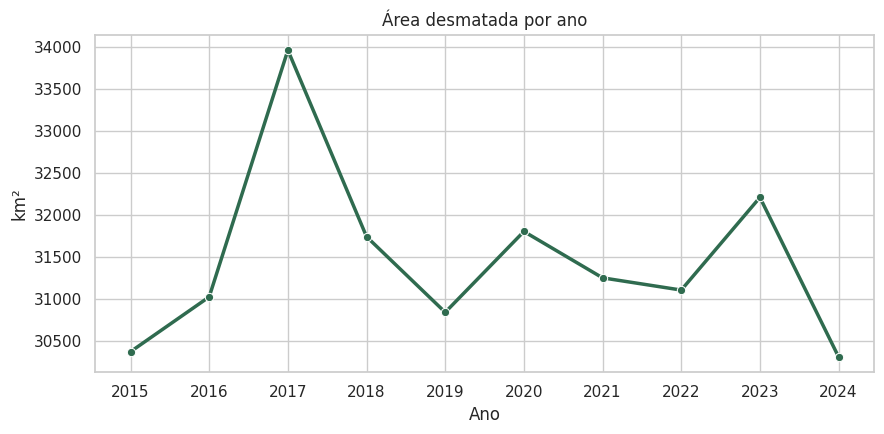

In [15]:
verde = "#2f6b4f"
anual_plot = anual.reset_index()

fig, ax = plt.subplots(figsize=(9, 4.5))
sns.lineplot(data=anual_plot, x="ano", y="total_km2", marker="o", color=verde, linewidth=2.5, ax=ax)
ax.set_title("Área desmatada por ano")
ax.set_xlabel("Ano")
ax.set_ylabel("km²")
ax.set_xticks(anual_plot["ano"])
plt.tight_layout()
plt.savefig("../imagens/01_desmatamento_anual.png", dpi=150)
plt.show()

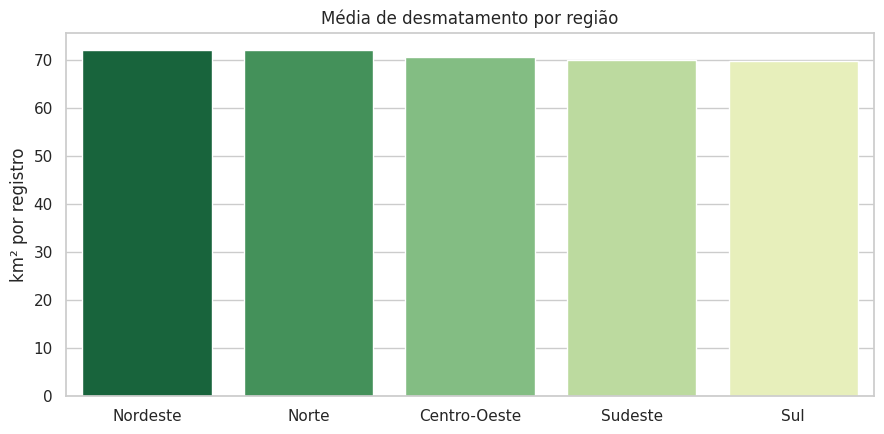

In [16]:
fig, ax = plt.subplots(figsize=(9, 4.5))
dados_regiao = por_regiao.reset_index()
sns.barplot(data=dados_regiao, x="regiao", y="media_km2", hue="regiao", palette="YlGn_r", legend=False, ax=ax)
ax.set_title("Média de desmatamento por região")
ax.set_xlabel("")
ax.set_ylabel("km² por registro")
plt.tight_layout()
plt.savefig("../imagens/02_desmatamento_regiao.png", dpi=150)
plt.show()

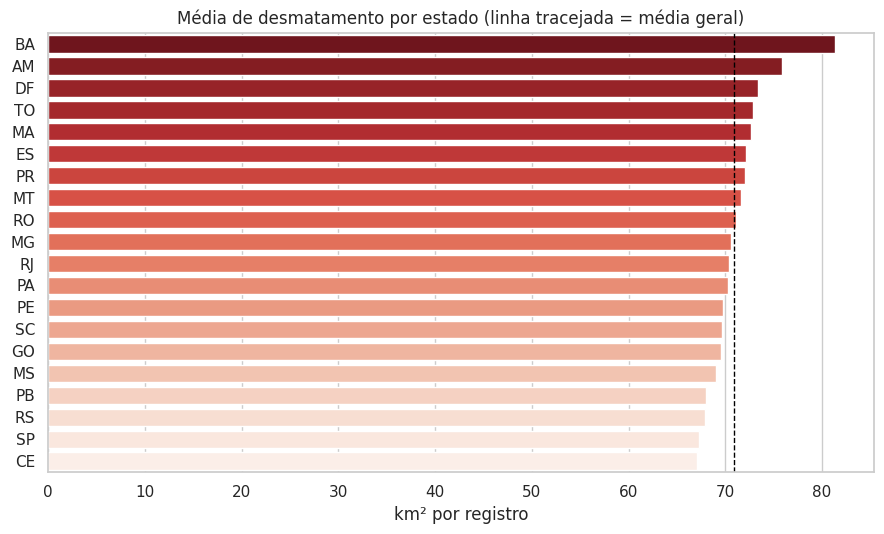

In [17]:
fig, ax = plt.subplots(figsize=(9, 5.5))
dados_uf = por_uf.reset_index()
sns.barplot(data=dados_uf, y="uf", x="area_desmatada_km2", hue="uf", palette="Reds_r", legend=False, ax=ax)
ax.axvline(df["area_desmatada_km2"].mean(), color="black", linestyle="--", linewidth=1)
ax.set_title("Média de desmatamento por estado (linha tracejada = média geral)")
ax.set_xlabel("km² por registro")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig("../imagens/03_media_por_estado.png", dpi=150)
plt.show()

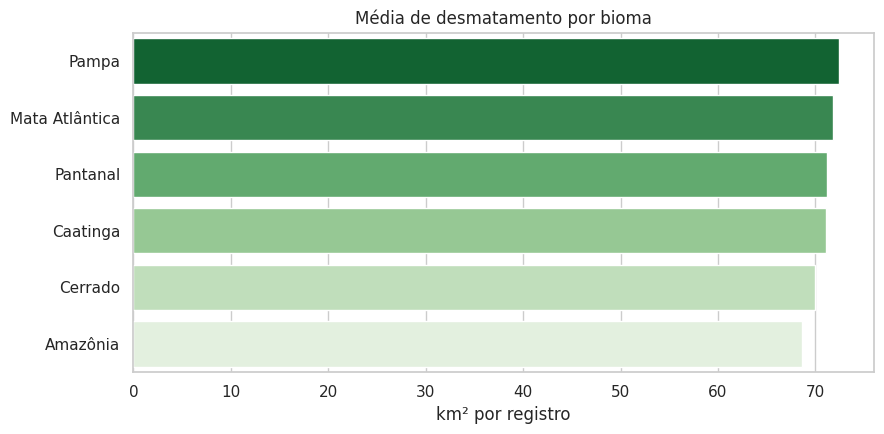

In [18]:
fig, ax = plt.subplots(figsize=(9, 4.5))
dados_bioma = por_bioma.reset_index()
sns.barplot(data=dados_bioma, y="bioma", x="area_desmatada_km2", hue="bioma", palette="Greens_r", legend=False, ax=ax)
ax.set_title("Média de desmatamento por bioma")
ax.set_xlabel("km² por registro")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig("../imagens/04_desmatamento_bioma.png", dpi=150)
plt.show()

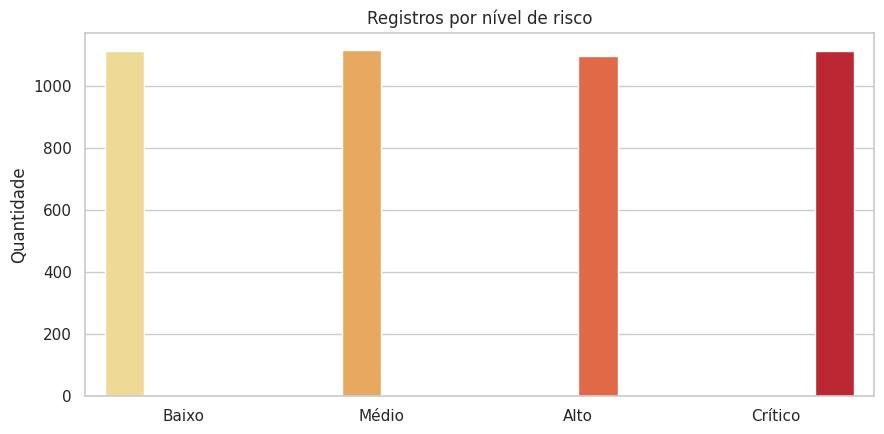

In [19]:
fig, ax = plt.subplots(figsize=(9, 4.5))
sns.countplot(data=df, x="nivel_risco", hue="nivel_risco", palette="YlOrRd", legend=False, ax=ax)
ax.set_title("Registros por nível de risco")
ax.set_xlabel("")
ax.set_ylabel("Quantidade")
plt.tight_layout()
plt.savefig("../imagens/05_nivel_risco.png", dpi=150)
plt.show()

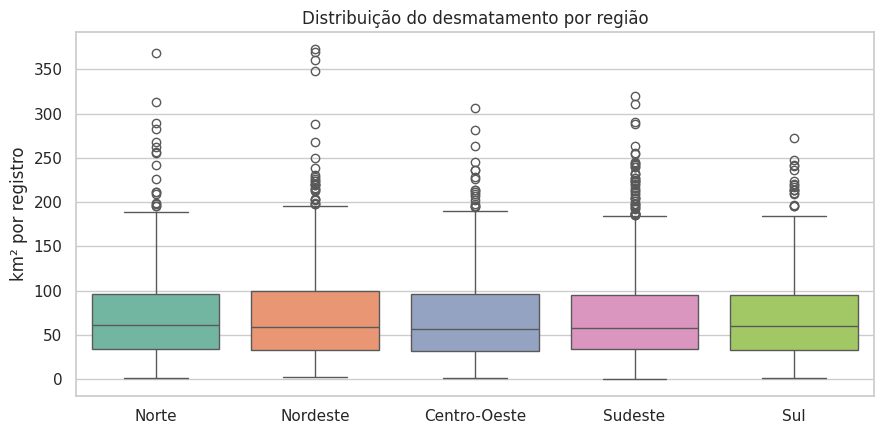

In [20]:
fig, ax = plt.subplots(figsize=(9, 4.5))
sns.boxplot(data=df, x="regiao", y="area_desmatada_km2", hue="regiao", palette="Set2", legend=False, ax=ax)
ax.set_title("Distribuição do desmatamento por região")
ax.set_xlabel("")
ax.set_ylabel("km² por registro")
plt.tight_layout()
plt.savefig("../imagens/06_boxplot_regiao.png", dpi=150)
plt.show()

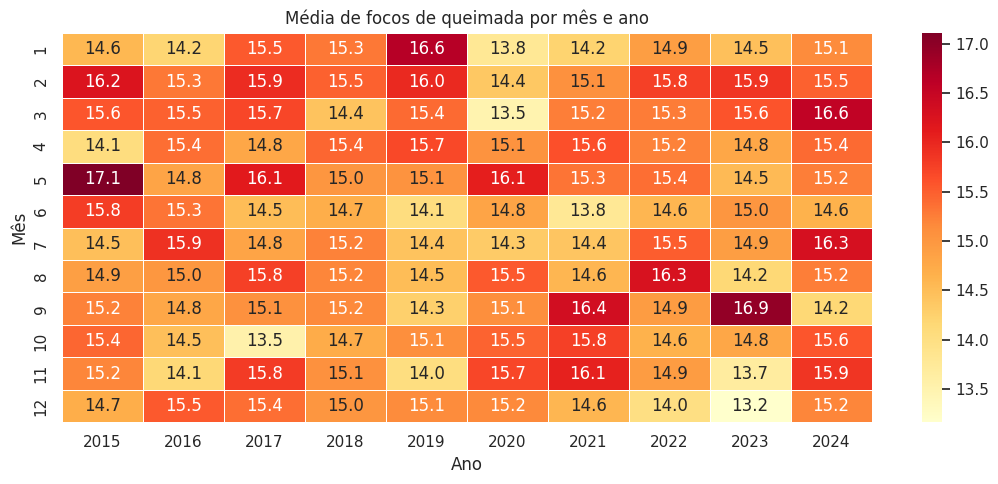

In [21]:
focos = df.pivot_table(index="mes", columns="ano", values="focos_queimada", aggfunc="mean")

fig, ax = plt.subplots(figsize=(11, 5))
sns.heatmap(focos, cmap="YlOrRd", annot=True, fmt=".1f", linewidths=0.4, ax=ax)
ax.set_title("Média de focos de queimada por mês e ano")
ax.set_xlabel("Ano")
ax.set_ylabel("Mês")
plt.tight_layout()
plt.savefig("../imagens/07_focos_mes_ano.png", dpi=150)
plt.show()

## 9. Correlação estatística

Uso a correlação de Pearson, que vai de -1 a 1. Valores próximos de 0 indicam ausência de relação linear.

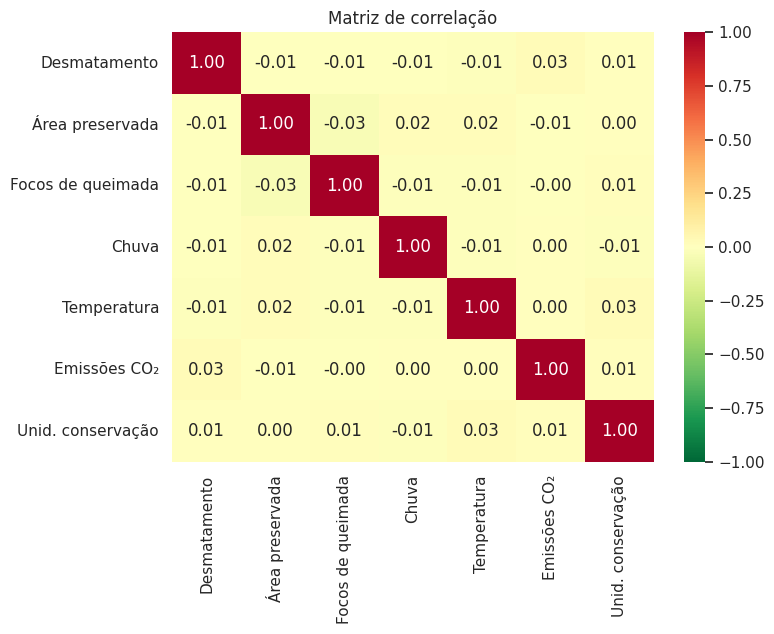

In [22]:
nomes = {
    "area_desmatada_km2": "Desmatamento",
    "area_preservada_km2": "Área preservada",
    "focos_queimada": "Focos de queimada",
    "chuva_mm": "Chuva",
    "temperatura_media": "Temperatura",
    "emissoes_co2": "Emissões CO₂",
    "unidades_conservacao": "Unid. conservação",
}
correlacao = df[colunas_numericas].corr().rename(index=nomes, columns=nomes)

fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(correlacao, annot=True, fmt=".2f", cmap="RdYlGn_r", center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title("Matriz de correlação")
plt.tight_layout()
plt.savefig("../imagens/08_correlacao.png", dpi=150)
plt.show()

In [23]:
correlacao["Desmatamento"].drop("Desmatamento").sort_values(key=abs, ascending=False).round(3)

Emissões CO₂         0.03
Temperatura         -0.01
Focos de queimada   -0.01
Área preservada     -0.01
Unid. conservação    0.01
Chuva               -0.01
Name: Desmatamento, dtype: float64

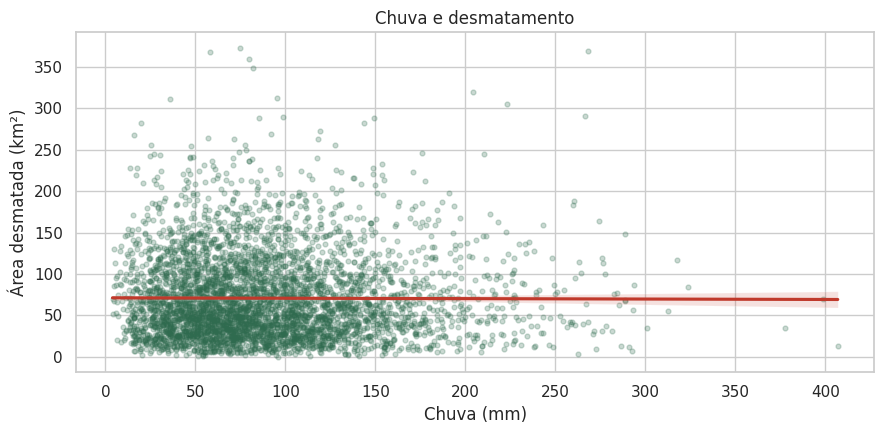

In [24]:
fig, ax = plt.subplots(figsize=(9, 4.5))
sns.regplot(
    data=df, x="chuva_mm", y="area_desmatada_km2",
    scatter_kws={"alpha": 0.25, "s": 12, "color": verde}, line_kws={"color": "#c0392b"}, ax=ax,
)
ax.set_title("Chuva e desmatamento")
ax.set_xlabel("Chuva (mm)")
ax.set_ylabel("Área desmatada (km²)")
plt.tight_layout()
plt.savefig("../imagens/09_chuva_desmatamento.png", dpi=150)
plt.show()

## 10. Interpretação dos resultados

**Evolução no tempo.** O total anual oscilou entre cerca de 30,3 mil km² (2024) e 34,0 mil km² (2017). O pico de 2017 está cerca de 10,8% acima do valor de 2024, mas não existe uma tendência clara de alta ou queda: 2015 e 2024 terminam praticamente no mesmo patamar.

**Regiões, estados e biomas.** O Sudeste lidera em total apenas porque tem mais registros. Na média por registro, as regiões variam pouco (69,8 a 72,1 km²). Entre os estados, a Bahia se destaca com 81,3 km² por registro, cerca de 15% acima da média geral de 70,9 km², seguida do Amazonas (75,9). O Ceará tem a menor média (67,1). Entre os biomas, a diferença vai de 68,6 (Amazônia) a 72,4 km² (Pampa).

**Risco.** Os quatro níveis têm praticamente o mesmo número de registros, e cerca de 49,8% estão em risco Alto ou Crítico. Metade da base, portanto, exige atenção.

**Queimadas e clima.** A média de focos por mês fica sempre perto de 15, sem uma estação do ano claramente pior.

**Correlação.** Todas as correlações com o desmatamento são praticamente nulas. A maior, com as emissões de CO₂, é de apenas 0,03. Nenhuma variável sozinha explica o desmatamento nesta base. Isso é coerente com dados simulados e reforça um cuidado importante: correlação baixa não prova que não existe relação no mundo real, só que ela não aparece nestes dados.

## 11. Conclusão

A análise mostrou que o desmatamento nesta base é estável ao longo de 2015 a 2024, com variações anuais de poucos pontos percentuais e sem diferenças marcantes entre regiões ou biomas quando comparo médias. A Bahia e o Amazonas são os estados com as maiores médias e merecem atenção em um monitoramento priorizado.

Também ficou claro que comparar totais pode enganar quando os grupos têm tamanhos diferentes, como no caso do Sudeste. Usar médias por registro deixou a comparação mais justa.

Como limitação, a base é simulada. Os resultados servem para demonstrar o processo de análise, mas não para tirar conclusões ambientais reais. O próximo passo seria repetir o estudo com dados oficiais, como os do INPE (PRODES e Queimadas), e o dashboard em Streamlit deste projeto já está preparado para receber esse tipo de dado.

---
Projeto desenvolvido por **Thalles Órion Volcov Pitz**.